# 🌊 Week 1 Lab — Data Stream Mining Toolkit & Prerequisite Refresher

**Data Stream Mining — NOVA IMS**  
**Week 1 Laboratory**

---

## Why this notebook exists

This notebook is **not an assessment**. It is a **reference notebook** that you can revisit throughout the semester.

It has four goals:

1. Check that your Python environment is ready.
2. Refresh the Python, statistics, mathematics, and Machine Learning concepts assumed by the course.
3. Introduce the main software tools we will use.
4. Give you a first executable example of the **streaming mindset**.

### How to read the notebook

- 🟢 **MUST KNOW** — you should be comfortable with this.
- 🟡 **REFRESH IF NEEDED** — use this section whenever you need a reminder.
- 🔵 **COURSE TOOL** — a tool or idea that will appear again later in the semester.
- ✍️ **TRY IT YOURSELF** — small activity; no submission is required.

> **Main idea:** You already know many of the building blocks.  
> In this course, several assumptions change: data arrives continuously, resources are limited, evaluation is continuous, and the environment may evolve.

## 0. From Batch Machine Learning to Data Stream Mining

### 📚 What you already know

- Python
- Data preparation
- Statistics and probability
- Classification and regression
- Clustering
- Model evaluation

### 🚀 What changes in this course

| Traditional setting | Streaming setting |
|---|---|
| Batch processing | Continuous processing |
| Offline learning | Incremental / online learning |
| Fixed train/test evaluation | Continuous evaluation |
| Stored dataset | Potentially infinite stream |
| Stable assumptions | Evolving environment |
| Multiple passes over data | Often one pass |

A useful mental model for the semester is:

**OBSERVE → PREDICT → EVALUATE → LEARN → REPEAT**

# 1. Environment Setup

## 🟢 MUST KNOW — Python and package management

We will mainly use:

- **NumPy** — numerical computing
- **Pandas** — tabular data manipulation
- **Matplotlib** — visualization
- **SciPy** — scientific computing
- **scikit-learn** — traditional/batch Machine Learning
- **River** — online and incremental Machine Learning

River currently targets modern Python versions. If you have environment problems, check your Python version first.

### Installation

Run the next cell **only if you need to install the packages**.

After installation, you may need to restart the Jupyter kernel.

In [1]:
# Uncomment and run if the packages are not installed.
# In Jupyter, %pip installs packages into the current Python environment.

%pip install -q numpy pandas matplotlib scipy scikit-learn river

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Check the Python version used by this notebook
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\psouza\Desktop\Data Stream Mining\.venv\Scripts\python.exe
Python version: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


In [2]:
# Import the core libraries we will use in this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.5.3
Pandas: 3.0.5


## 🔵 COURSE TOOL — Reproducibility

Many experiments contain randomness. A **random seed** makes an experiment easier to reproduce.

This will matter when we compare algorithms later in the semester.

In [3]:
SEED = 42
rng = np.random.default_rng(SEED)

# Generate the same random values every time the notebook is restarted
rng.normal(size=5)

array([ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519])

# 2. Python Essentials for Streaming

## 🟢 MUST KNOW

The goal is not to review all of Python. We focus on constructs that are especially useful when processing observations sequentially:

- lists and dictionaries
- loops and conditionals
- functions
- iterators
- generators

A data stream is naturally represented as something we can iterate over **one observation at a time**.

In [4]:
# Lists: ordered collections
temperatures = [20.1, 20.3, 20.4, 20.2, 20.8]

print("First value:", temperatures[0])
print("Number of observations:", len(temperatures))

First value: 20.1
Number of observations: 5


In [5]:
# Dictionaries: a common representation for one observation
observation = {
    "temperature": 20.4,
    "humidity": 0.61,
    "pressure": 1013.2
}

print(observation)
print("Temperature:", observation["temperature"])

{'temperature': 20.4, 'humidity': 0.61, 'pressure': 1013.2}
Temperature: 20.4


In [6]:
# Loops: process observations sequentially
for value in temperatures:
    print("New observation:", value)

New observation: 20.1
New observation: 20.3
New observation: 20.4
New observation: 20.2
New observation: 20.8


In [7]:
# Functions: reusable pieces of logic
def is_high_temperature(value, threshold=20.5):
    return value > threshold

for value in temperatures:
    print(value, "-> high?", is_high_temperature(value))

20.1 -> high? False
20.3 -> high? False
20.4 -> high? False
20.2 -> high? False
20.8 -> high? True


## 🟢 MUST KNOW — Iterators and Generators

This concept is particularly important for streaming.

A **generator** can produce values one at a time instead of creating the entire sequence in memory first.

In [8]:
def temperature_stream():
    # Yield one observation at a time.
    values = [20.1, 20.3, 20.4, 20.2, 20.8]
    for value in values:
        yield value

stream = temperature_stream()

print(next(stream))
print(next(stream))
print(next(stream))

20.1
20.3
20.4


In [9]:
# A generator can be consumed with a for-loop
for value in temperature_stream():
    print("Processing:", value)

Processing: 20.1
Processing: 20.3
Processing: 20.4
Processing: 20.2
Processing: 20.8


### ✍️ TRY IT YOURSELF

Create a generator called `transaction_stream()` that yields five transaction amounts.

Then process each amount and print whether it is above a threshold of 100.

In [10]:
# TODO: Try it yourself

def transaction_stream():
    amounts = [25, 120, 55, 240, 90]
    for amount in amounts:
        yield amount

for amount in transaction_stream():
    print(amount, "-> above 100?", amount > 100)

25 -> above 100? False
120 -> above 100? True
55 -> above 100? False
240 -> above 100? True
90 -> above 100? False


# 3. NumPy Essentials

## 🟡 REFRESH IF NEEDED

NumPy provides efficient numerical arrays and mathematical operations.

We will often use it to:

- manipulate numeric data,
- compute summary statistics,
- simulate data,
- support experiments and visualizations.

In [11]:
x = np.array([2.0, 4.0, 5.0, 7.0, 12.0])

print("Array:", x)
print("Shape:", x.shape)
print("Mean:", np.mean(x))
print("Median:", np.median(x))
print("Variance:", np.var(x))
print("Standard deviation:", np.std(x))
print("Minimum:", np.min(x))
print("Maximum:", np.max(x))

Array: [ 2.  4.  5.  7. 12.]
Shape: (5,)
Mean: 6.0
Median: 5.0
Variance: 11.6
Standard deviation: 3.40587727318528
Minimum: 2.0
Maximum: 12.0


### Mathematics → Python

For observations $x_1,\ldots,x_n$, the sample mean is

$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$

In NumPy:

```python
np.mean(x)
```

The important question for this course will be:

> **Can we update a statistic without keeping every previous observation?**

We will answer that later in this notebook.

In [12]:
# Vectors and dot products
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])

print("a · b =", np.dot(a, b))
print("Equivalent expression =", a @ b)

a · b = 32.0
Equivalent expression = 32.0


In [16]:
# Random data generation
samples = rng.normal(loc=10, scale=2, size=1000)

print("Approximate mean:", samples.mean())
print("Approximate standard deviation:", samples.std())

Approximate mean: 10.003083397667254
Approximate standard deviation: 1.951342116183861


# 4. Pandas Essentials

## 🟢 MUST KNOW

Pandas is extremely useful for static tabular datasets.

One reason to review it now is that it highlights an important contrast:

> Pandas often encourages us to think about the **whole dataset at once**.  
> Data Stream Mining often forces us to think **one observation at a time**.

In [37]:
df = pd.DataFrame({
    "temperature": [20.1, 20.3, 20.4, 20.2, 20.8],
    "humidity": [0.60, 0.63, 0.61, 0.66, 0.58],
    "alert": [0, 0, 0, 0, 1]
})

df

,temperature,humidity,alert
0,20.1,0.60,0
1,20.3,0.63,0
2,20.4,0.61,0
3,20.2,0.66,0
4,20.8,0.58,1


In [18]:
# Basic inspection
print(df.shape)
print(df.columns.tolist())
df.describe()

(5, 3)
['temperature', 'humidity', 'alert']


,temperature,humidity,alert
count,5.000000,5.000000,5.000000
mean,20.360000,0.616000,0.200000
std,0.270185,0.030496,0.447214
min,20.100000,0.580000,0.000000
25%,20.200000,0.600000,0.000000
50%,20.300000,0.610000,0.000000
75%,20.400000,0.630000,0.000000
max,20.800000,0.660000,1.000000


In [19]:
# Selecting features X and target y
X = df[["temperature", "humidity"]]
y = df["alert"]

print("Features:")
display(X)

print("Target:")
display(y)

Features:


,temperature,humidity
0,20.1,0.60
1,20.3,0.63
2,20.4,0.61
3,20.2,0.66
4,20.8,0.58


Target:


0    0
1    0
2    0
3    0
4    1
Name: alert, dtype: int64

In [20]:
# Filtering observations
high_temperature = df[df["temperature"] > 20.3]
high_temperature

,temperature,humidity,alert
2,20.4,0.61,0
4,20.8,0.58,1


### ✍️ TRY IT YOURSELF

Change the filtering condition above.

Examples:

- humidity greater than 0.60;
- temperature below the mean;
- observations where `alert == 1`.

In [21]:
# TODO: Change this condition
df[df["humidity"] > 0.60]

,temperature,humidity,alert
1,20.3,0.63,0
2,20.4,0.61,0
3,20.2,0.66,0


# 5. Statistics Refresher

## 🟡 REFRESH IF NEEDED

Statistics is central to Data Stream Mining because we continually ask:

- What is normal?
- Has the distribution changed?
- Is a new observation unusual?
- Is the model improving or degrading?

In [22]:
values = np.array([10, 11, 11, 12, 13, 13, 14, 30])

summary = {
    "mean": np.mean(values),
    "median": np.median(values),
    "variance": np.var(values),
    "std": np.std(values),
    "q25": np.quantile(values, 0.25),
    "q75": np.quantile(values, 0.75),
}

summary

{'mean': np.float64(14.25),
 'median': np.float64(12.5),
 'variance': np.float64(36.9375),
 'std': np.float64(6.077622890571609),
 'q25': np.float64(11.0),
 'q75': np.float64(13.25)}

Notice the value `30`.

Ask yourself:

- Is it an error?
- Is it an anomaly?
- Is it evidence that the process is changing?

Those questions will return later in the course.

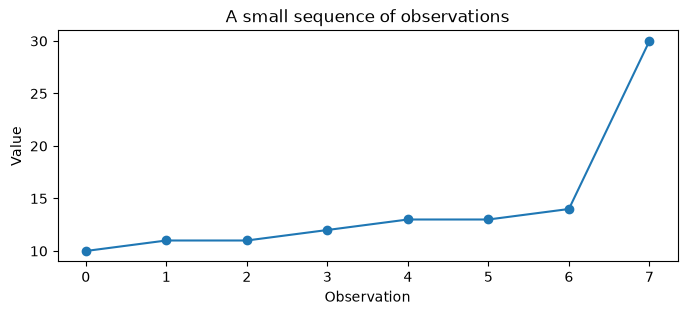

In [23]:
# Visualize the observations
plt.figure(figsize=(8, 3))
plt.plot(values, marker="o")
plt.xlabel("Observation")
plt.ylabel("Value")
plt.title("A small sequence of observations")
plt.show()

## Probability concepts to remember

You do not need a full probability course here, but you should remember:

- **Random variable**
- **Probability distribution**
- **Expected value**
- **Variance**
- **Conditional probability**

Concept drift will later force us to think about what happens when the distribution generating the data changes over time.

In [24]:
# Bernoulli experiment: 1 = event, 0 = no event
bernoulli_samples = rng.binomial(n=1, p=0.3, size=20)

print(bernoulli_samples)
print("Observed event frequency:", bernoulli_samples.mean())

[1 0 0 0 0 1 0 1 1 1 0 0 1 1 0 1 0 0 1 0]
Observed event frequency: 0.45


# 6. Linear Algebra Refresher

## 🟡 REFRESH IF NEEDED

For this course, remember the basic objects:

- scalar
- vector
- matrix
- dimensions / shape
- dot product
- norm

Many Machine Learning algorithms are expressed using these objects.

In [25]:
scalar = 3.0
vector = np.array([1.0, 2.0, 3.0])
matrix = np.array([
    [1.0, 2.0],
    [3.0, 4.0],
    [5.0, 6.0]
])

print("Scalar:", scalar)
print("Vector shape:", vector.shape)
print("Matrix shape:", matrix.shape)
print("Vector norm:", np.linalg.norm(vector))

Scalar: 3.0
Vector shape: (3,)
Matrix shape: (3, 2)
Vector norm: 3.7416573867739413


# 7. Machine Learning Refresher

## 🟢 MUST KNOW

### Supervised learning

We observe features \(X\) and a target \(y\), and learn a mapping:
$
X \rightarrow model \rightarrow \hat{y}
$

You should remember the difference between:

- **Classification** — predict a category.
- **Regression** — predict a numeric value.
- **Clustering** — discover structure without a target variable.

You should also be comfortable with:

- training and testing,
- overfitting and underfitting,
- preprocessing,
- model evaluation.

In [26]:
# A small batch Machine Learning example with scikit-learn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    random_state=SEED
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

batch_model = LogisticRegression(max_iter=1000)
batch_model.fit(X_train, y_train)

y_pred = batch_model.predict(X_test)

print("Batch test accuracy:", accuracy_score(y_test, y_pred))

Batch test accuracy: 0.8466666666666667


### The familiar batch API

```python
model.fit(X_train, y_train)
predictions = model.predict(X_test)
```

This assumes we have a dataset available for training.

A central question in Data Stream Mining is:

> **What if observations arrive continuously and we want the model to update immediately?**

# 8. Evaluation Refresher

## 🟢 MUST KNOW

For classification, remember:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

For regression, remember:

- MAE
- MSE
- RMSE

The formulas are familiar.

What will change in this course is **how and when we compute them**.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8466666666666667
Precision: 0.8354430379746836
Recall: 0.868421052631579
F1: 0.8516129032258064
Confusion matrix:
[[61 13]
 [10 66]]


> ⚠️ **Important**

In traditional Machine Learning, we often report one final metric after training.

In streaming environments, performance can change over time.

Later in the course we will ask:

- How is the model performing **now**?
- Should recent observations matter more?
- Did performance drop because the environment changed?
- How quickly did the model recover?

# 9. Your First Data Stream

## 🔵 COURSE TOOL — Incremental thinking

Consider a stream of temperature measurements.

A batch approach stores all observations and computes:

```python
np.mean(all_values)
```

But what if the stream never ends?

We can update the mean incrementally.

In [28]:
temperature_values = [20.1, 20.3, 20.4, 20.2, 20.8, 21.0, 20.7]

running_sum = 0.0
count = 0

for value in temperature_values:
    count += 1
    running_sum += value
    running_mean = running_sum / count

    print(
        f"Observation {count}: value={value:.1f} "
        f"| running mean={running_mean:.3f}"
    )

Observation 1: value=20.1 | running mean=20.100
Observation 2: value=20.3 | running mean=20.200
Observation 3: value=20.4 | running mean=20.267
Observation 4: value=20.2 | running mean=20.250
Observation 5: value=20.8 | running mean=20.360
Observation 6: value=21.0 | running mean=20.467
Observation 7: value=20.7 | running mean=20.500


The previous solution already avoids recomputing the mean from scratch.

We can go one step further. If the current mean is $\mu_{n-1}$, then after receiving $x_n$:

$
\mu_n = \mu_{n-1} + \frac{x_n - \mu_{n-1}}{n}
$

This update requires only:

- the previous mean,
- the new value,
- the number of observations.

We do **not** need to keep the full history.

In [29]:
mean = 0.0

for n, value in enumerate(temperature_values, start=1):
    mean = mean + (value - mean) / n
    print(f"n={n:2d} | value={value:4.1f} | incremental mean={mean:.3f}")

n= 1 | value=20.1 | incremental mean=20.100
n= 2 | value=20.3 | incremental mean=20.200
n= 3 | value=20.4 | incremental mean=20.267
n= 4 | value=20.2 | incremental mean=20.250
n= 5 | value=20.8 | incremental mean=20.360
n= 6 | value=21.0 | incremental mean=20.467
n= 7 | value=20.7 | incremental mean=20.500


In [30]:
# Verify that the incremental calculation matches NumPy
print("Incremental mean:", mean)
print("NumPy mean:", np.mean(temperature_values))
print("Difference:", abs(mean - np.mean(temperature_values)))

Incremental mean: 20.5
NumPy mean: 20.5
Difference: 0.0


### ✍️ TRY IT YOURSELF

Modify the stream by adding new values.

Questions:

1. Does the incremental mean always match `np.mean()`?
2. What happens if you add a very large value?
3. Which approach would be easier to use if 100 million observations arrived?

In [31]:
# TODO: Add or change observations
my_stream = [5, 7, 8, 9, 10, 12]

mean = 0.0

for n, value in enumerate(my_stream, start=1):
    mean += (value - mean) / n

print("Incremental mean:", mean)
print("Batch mean:", np.mean(my_stream))

Incremental mean: 8.5
Batch mean: 8.5


# 10. Meet River 🌊

## 🔵 COURSE TOOL

**River** is a Python library designed for online and incremental Machine Learning.

Its API reflects the streaming mindset.

Typical operations include:

- `predict_one(x)` — predict one observation,
- `learn_one(x, y)` — learn from one observation,
- online metrics that update one result at a time,
- incremental preprocessing,
- drift detection,
- clustering,
- anomaly detection,
- ensembles.

The important pattern is:

**PREDICT → EVALUATE → LEARN → REPEAT**

In [32]:
# Check whether River is available

try:
    import river
    print("River version:", river.__version__)
    RIVER_AVAILABLE = True
except ImportError:
    RIVER_AVAILABLE = False
    print(
        "River is not installed in this environment.\n"
        "Run the installation cell at the beginning of the notebook, "
        "restart the kernel, and run this cell again."
    )

River version: 0.26.1


In [ ]:
# First River example: an incremental statistic

if RIVER_AVAILABLE:
    from river import stats

    online_mean = stats.Mean()

    for value in temperature_values:
        online_mean.update(value)
        print(
            f"value={value:4.1f} | "
            f"River running mean={online_mean.get():.3f}"
        )
else:
    print("Install River first to run this example.")

value=20.1 | River running mean=20.100
value=20.3 | River running mean=20.200
value=20.4 | River running mean=20.267
value=20.2 | River running mean=20.250
value=20.8 | River running mean=20.360
value=21.0 | River running mean=20.467
value=20.7 | River running mean=20.500


## A first incremental classifier

We deliberately keep this example simple.

The objective today is **not** to understand Logistic Regression in detail.

The objective is to observe the workflow:

1. receive one observation,
2. predict,
3. evaluate,
4. learn from that observation,
5. continue.

In [34]:
if RIVER_AVAILABLE:
    from river import compose
    from river import linear_model
    from river import metrics
    from river import preprocessing

    tiny_stream = [
        ({"x1": 0.1, "x2": 0.2}, False),
        ({"x1": 0.2, "x2": 0.1}, False),
        ({"x1": 0.8, "x2": 0.9}, True),
        ({"x1": 0.9, "x2": 0.8}, True),
        ({"x1": 0.3, "x2": 0.2}, False),
        ({"x1": 0.7, "x2": 0.8}, True),
        ({"x1": 0.4, "x2": 0.3}, False),
        ({"x1": 0.85, "x2": 0.75}, True),
    ]

    model = compose.Pipeline(
        preprocessing.StandardScaler(),
        linear_model.LogisticRegression()
    )

    metric = metrics.Accuracy()

    for i, (x_i, y_i) in enumerate(tiny_stream, start=1):
        y_pred = model.predict_one(x_i)

        if y_pred is not None:
            metric.update(y_i, y_pred)

        model.learn_one(x_i, y_i)

        print(
            f"Observation {i}: true={y_i}, "
            f"predicted={y_pred}, metric={metric}"
        )
else:
    print("Install River first to run this example.")

Observation 1: true=False, predicted=False, metric=Accuracy: 100.00%
Observation 2: true=False, predicted=False, metric=Accuracy: 100.00%
Observation 3: true=True, predicted=False, metric=Accuracy: 66.67%
Observation 4: true=True, predicted=True, metric=Accuracy: 75.00%
Observation 5: true=False, predicted=False, metric=Accuracy: 80.00%
Observation 6: true=True, predicted=True, metric=Accuracy: 83.33%
Observation 7: true=False, predicted=False, metric=Accuracy: 85.71%
Observation 8: true=True, predicted=True, metric=Accuracy: 87.50%


### Compare the two mental models

#### Batch Machine Learning

```python
model.fit(X_train, y_train)
predictions = model.predict(X_test)
```

#### Streaming Machine Learning

```python
for x, y in stream:
    prediction = model.predict_one(x)
    metric.update(y, prediction)
    model.learn_one(x, y)
```

Do not worry about memorizing the River syntax today.

Focus on the sequence:

> **The model is evaluated and updated while the data is arriving.**

# 11. A Simple Performance-Over-Time Example

A single final accuracy value can hide changes in model behavior.

The next example creates a sequence of correct/incorrect predictions and computes accuracy over time.

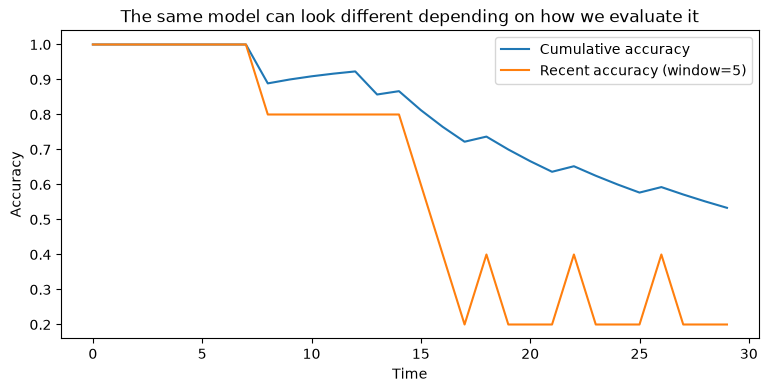

In [35]:
# 1 = correct prediction, 0 = incorrect prediction
prediction_results = np.array(
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
     1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
     0, 0, 1, 0, 0, 0, 1, 0, 0, 0]
)

cumulative_accuracy = np.cumsum(prediction_results) / np.arange(
    1, len(prediction_results) + 1
)

window_size = 5
rolling_accuracy = (
    pd.Series(prediction_results)
    .rolling(window=window_size, min_periods=1)
    .mean()
    .to_numpy()
)

plt.figure(figsize=(9, 4))
plt.plot(cumulative_accuracy, label="Cumulative accuracy")
plt.plot(rolling_accuracy, label=f"Recent accuracy (window={window_size})")
plt.xlabel("Time")
plt.ylabel("Accuracy")
plt.title("The same model can look different depending on how we evaluate it")
plt.legend()
plt.show()

### Think about it

- Which curve reacts faster when performance deteriorates?
- Which curve remembers the distant past?
- If you had to decide whether the model is currently reliable, which curve would you prefer?

We will formalize these ideas later when we study **online and prequential evaluation**.

# 12. Library Map for the Semester

## Core Python ecosystem

| Library | Main role |
|---|---|
| `numpy` | Numerical arrays, simulation, mathematical operations |
| `pandas` | Tabular data manipulation |
| `matplotlib` | Visualization |
| `scipy` | Scientific and statistical computing |

## Machine Learning

| Library | Main role |
|---|---|
| `scikit-learn` | Traditional/batch Machine Learning |
| `river` | Online and incremental Machine Learning |

## What River will help us explore

During the semester, River can support experiments involving:

- incremental classifiers,
- online preprocessing,
- online metrics,
- decision trees,
- ensembles,
- drift detection,
- clustering,
- anomaly detection,
- model pipelines.

> We will introduce tools progressively. You are **not expected to learn the entire library in Week 1**.

# 13. Reusable Patterns — Keep These for Later

## Pattern A — Process a stream

```python
for observation in stream:
    process(observation)
```

## Pattern B — Update a statistic

```python
for value in stream:
    statistic.update(value)
```

## Pattern C — Online supervised learning

```python
for x, y in stream:
    y_pred = model.predict_one(x)
    metric.update(y, y_pred)
    model.learn_one(x, y)
```

## Pattern D — Monitor performance over time

```python
history.append(metric.get())
```

These patterns will appear repeatedly throughout the course.

# 14. Self-Check

There is **no submission** for this section.

Before Week 2, you should be comfortable answering the following questions.

### Python

1. What is the difference between a list and a generator?
2. Why might a generator be useful for a large stream?
3. How is one observation naturally represented with a Python dictionary?

### Statistics & Mathematics

4. What do mean and variance describe?
5. What is a vector?
6. Why might summary statistics be useful when we cannot store all observations?

### Machine Learning

7. What is the difference between classification, regression, and clustering?
8. What does `model.fit()` usually assume about the training data?
9. What does a confusion matrix summarize?

### Streaming

10. Why might storing the entire dataset become impossible?
11. Why might one final accuracy value be insufficient?
12. What is the logic behind **predict → evaluate → learn → repeat**?

> If some questions are difficult, revisit the relevant section of this notebook.  
> This notebook is intended to remain a reference throughout the semester.

# 15. Optional Practice

## ✍️ Mini-activity — Build a tiny stream

Create a stream of at least 20 numeric observations.

Then:

1. process observations one at a time;
2. compute the incremental mean;
3. store the running mean after each observation;
4. plot the observations and the running mean;
5. add one unusually large observation;
6. observe how the running mean reacts.

This is not graded. It is simply a way to practice the streaming mindset.

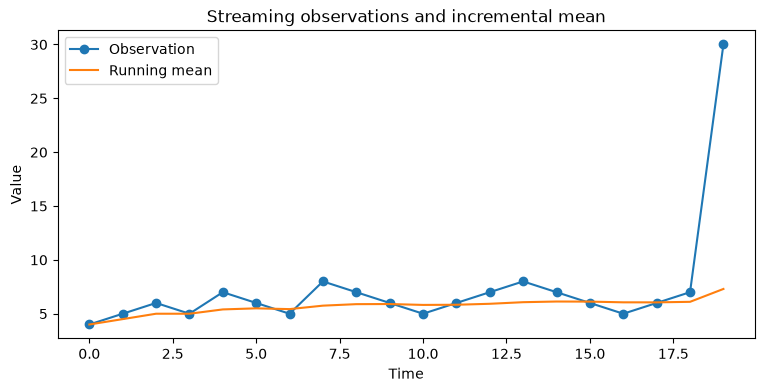

In [ ]:
# Starter code for the optional mini-activity

my_values = [4, 5, 6, 5, 7, 6, 5, 8, 7, 6,
             5, 6, 7, 8, 7, 6, 5, 6, 7, 30]

running_means = []
mean = 0.0

for n, value in enumerate(my_values, start=1):
    mean += (value - mean) / n
    running_means.append(mean)

plt.figure(figsize=(9, 4))
plt.plot(my_values, marker="o", label="Observation")
plt.plot(running_means, label="Running mean")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Streaming observations and incremental mean")
plt.legend()
plt.show()

# ✅ End of Week 1 Lab

Today, the most important transition was not from one Python library to another.

It was from this mindset:

**LOAD ALL DATA → TRAIN → TEST**

to this one:

**OBSERVE → PREDICT → EVALUATE → LEARN → REPEAT**

Next week, we begin formally with the **Foundations of Data Stream Mining**.